In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from pgmpy.models import BayesianModel
from pgmpy.estimators import (
    BicScore, HillClimbSearch,
    MaximumLikelihoodEstimator
)
from pgmpy.sampling import BayesianModelSampling

file_path = 'FASERIP.csv'
df = pd.read_csv(file_path)
# Calculate the 'Health' column
df['Health'] = df['F'] + df['A'] + df['S'] + df['E']

# Calculate the 'Karma' column
df['Karma'] = df['R'] + df['I'] + df['P']
print(df.head())
print(df.info())


/opt/miniconda3/envs/faserip_py/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ImportError: cannot import name 'BayesianModel' from 'pgmpy.models' (/opt/miniconda3/envs/faserip_py/lib/python3.12/site-packages/pgmpy/models/__init__.py)

In [ ]:
faserip_stat_columns = ['F', 'A','S','E','R','I','P']
average_stats = df[faserip_stat_columns].mean()
median_stats = df[faserip_stat_columns].median()
SD_stats = df[faserip_stat_columns].std()
Max_Stats = df[faserip_stat_columns].max()
Min_Stats = df[faserip_stat_columns].min()

print("Average:")
print(average_stats)
print("Median")
print(median_stats)
print("Std")
print(SD_stats)
print("Min")
print(Min_Stats)
print("Max")
print(Max_Stats)



Average:
F    23.195122
A    24.182927
S    27.646341
E    39.329268
R    15.170732
I    19.634146
P    22.487805
dtype: float64
Median
F    20.0
A    20.0
S    10.0
E    30.0
R    10.0
I    15.0
P    10.0
dtype: float64
Std
F    17.341479
A    14.773289
S    26.923473
E    22.943331
R    11.859054
I    16.548106
P    20.359876
dtype: float64
Min
F     4
A     6
S     4
E    10
R     2
I     4
P     2
dtype: int64
Max
F    100
A    100
S    100
E    100
R     50
I     75
P    100
dtype: int64


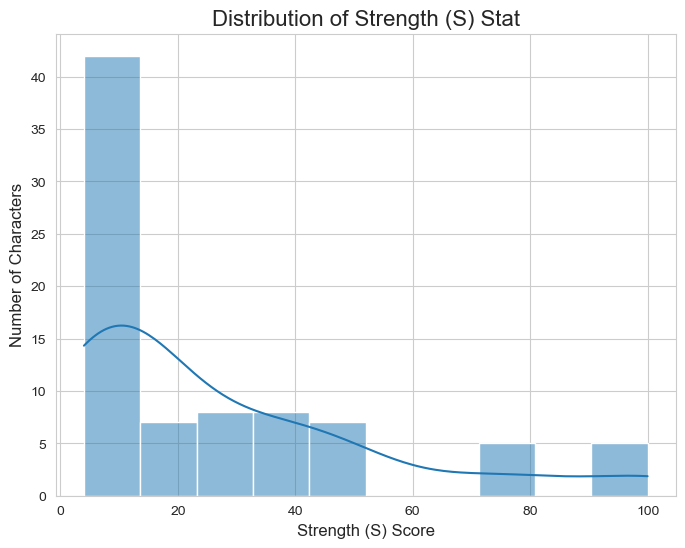

<Figure size 640x480 with 0 Axes>

In [ ]:
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.histplot(df['S'], bins=10, kde=True)

plt.title("Distribution of Strength (S) Stat", fontsize=16)
plt.xlabel("Strength (S) Score", fontsize=12)
plt.ylabel("Number of Characters", fontsize=12)

plt.show()

plt.savefig("Strength.png")




Type
Superhuman       26
Mutant           19
Technological    15
Human            12
Magical           3
God               3
Alien             2
Robot             2
Name: count, dtype: int64


/var/folders/wj/xzbvl19s7qdg2sxs_dz30hb80000gn/T/ipykernel_91237/707228278.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = type_counts.index, y=type_counts.values, palette="viridis")


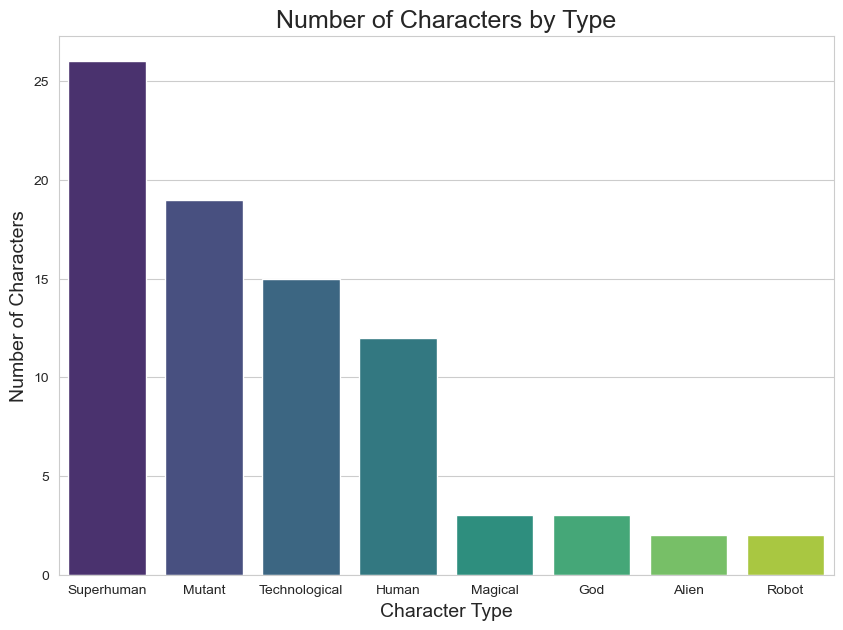

In [ ]:
type_counts = df['Type'].value_counts()

print(type_counts)

plt.figure(figsize=(10,7))
sns.barplot(x = type_counts.index, y=type_counts.values, palette="viridis")

plt.title("Number of Characters by Type", fontsize=18)
plt.xlabel("Character Type", fontsize=14)
plt.ylabel("Number of Characters", fontsize=14)

plt.show()


/var/folders/wj/xzbvl19s7qdg2sxs_dz30hb80000gn/T/ipykernel_91237/2938866907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='F', data=df, palette="coolwarm") # Using 'coolwarm' palette


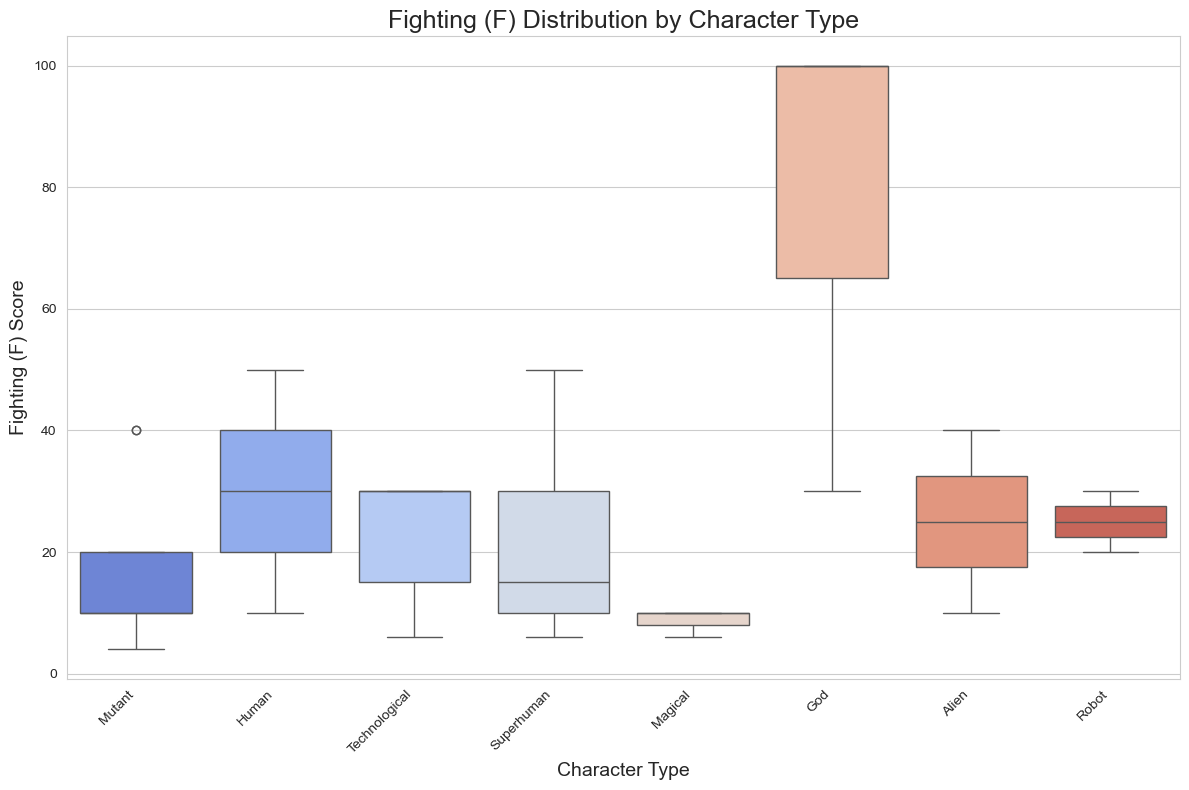

In [ ]:
sns.set_style("whitegrid") # Set a style for better aesthetics

plt.figure(figsize=(12, 8)) # Set a larger figure size for better readability
sns.boxplot(x='Type', y='F', data=df, palette="coolwarm") # Using 'coolwarm' palette

plt.title("Fighting (F) Distribution by Character Type", fontsize=18)
plt.xlabel("Character Type", fontsize=14)
plt.ylabel("Fighting (F) Score", fontsize=14)

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels if they are long
plt.tight_layout() # Adjust layout to prevent labels from being cut off

plt.show()

In [ ]:
unique_types = df['Type'].unique()
fighting_by_type_groups = [df['F'][df['Type'] == t] for t in unique_types]

f_statistic, p_value = stats.f_oneway(*fighting_by_type_groups)

print(f"F-stat: {f_statistic: .4f}")
print(f"P-value {p_value: .5f}")

tukey_result = pairwise_tukeyhsd(endog=df['F'],    # The numerical data you tested with ANOVA
                                 groups=df['Type'], # The categorical groups
                                 alpha=0.05)        # Significance level

print("\n--- Tukey's HSD Pairwise Comparisons for Fighting (F) Stat ---")
print(tukey_result)



F-stat:  8.0595
P-value  0.00000

--- Tukey's HSD Pairwise Comparisons for Fighting (F) Stat ---
       Multiple Comparison of Means - Tukey HSD, FWER=0.05        
  group1       group2    meandiff p-adj    lower    upper   reject
------------------------------------------------------------------
     Alien           God  51.6667 0.0022   12.7505  90.5829   True
     Alien         Human   3.3333    1.0  -29.2263   35.893  False
     Alien       Magical -16.3333 0.8926  -55.2495  22.5829  False
     Alien        Mutant  -8.7895 0.9882  -40.4807  22.9018  False
     Alien         Robot      0.0    1.0  -42.6306  42.6306  False
     Alien    Superhuman  -3.2308    1.0  -34.5131  28.0515  False
     Alien Technological  -2.8667    1.0  -34.9578  29.2245  False
       God         Human -48.3333    0.0  -75.8513 -20.8154   True
       God       Magical    -68.0    0.0 -102.8077 -33.1923   True
       God        Mutant -60.4561    0.0  -86.9408 -33.9714   True
       God         Robot -51.666

<Figure size 1000x800 with 0 Axes>

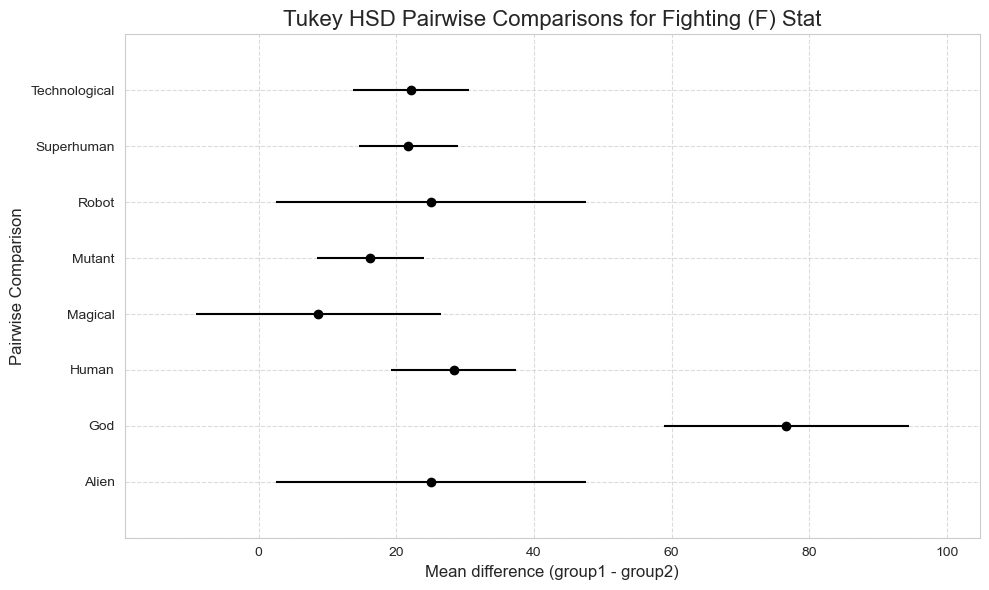

In [ ]:
plt.figure(figsize=(10, 8)) # Set a good figure size
tukey_result.plot_simultaneous()
plt.title("Tukey HSD Pairwise Comparisons for Fighting (F) Stat", fontsize=16)
plt.xlabel("Mean difference (group1 - group2)", fontsize=12)
plt.ylabel("Pairwise Comparison", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for readability
plt.tight_layout()
plt.show()

In [ ]:

from sklearn.mixture import GaussianMixture


X  = df[['F','A','S','E','R','I','P','Flight','Armour','Ranged']].values
gmm = GaussianMixture(n_components=3, random_state=42).fit(X)

# 2) Sample new stat‐vectors and get their cluster labels
new_stats, clusters = gmm.sample(50)
new_stats = np.clip(np.round(new_stats),
                    df[['F','A','S','E','R','I','P','Flight','Armour','Ranged']].min().values,
                    df[['F','A','S','E','R','I','P','Flight','Armour','Ranged']].max().values).astype(int)
new_df = pd.DataFrame(new_stats, columns=['F','A','S','E','R','I','P','Flight','Armour','Ranged'])

# 3) Build the cluster×Type count table from your original data
counts = (
    df.assign(cluster = gmm.predict(X))
      .groupby(['cluster','Type'])
      .size()
      .reset_index(name='count')
      .pivot(index='cluster', columns='Type', values='count')
      .fillna(0)
)

# 4) Normalize each row to get P(Type | cluster)
probs = counts.div(counts.sum(axis=1), axis=0)

# 5) For each new sample, draw its Type
type_choices = probs.columns.tolist()
new_df['Type'] = [
    np.random.choice(type_choices, p=probs.loc[c].values)
    for c in clusters
]

new_df

,F,A,S,E,R,I,P,Flight,Armour,Ranged,Type
0,6,23,8,29,23,4,2,0,104,23,Technological
1,13,40,22,26,17,12,39,109,59,25,Superhuman
2,17,25,25,62,9,19,44,74,37,19,Technological
3,63,51,44,54,9,18,9,48,28,0,Mutant
4,4,26,13,10,14,18,27,49,20,13,Superhuman
5,38,10,33,47,20,30,45,0,0,10,Mutant
6,25,19,56,63,2,12,45,41,0,35,Superhuman
7,4,34,4,10,17,43,29,0,31,47,Technological
8,17,27,19,52,14,4,2,42,196,34,Mutant
9,9,26,19,31,18,20,2,38,0,0,Mutant


In [ ]:

# 2) Estimate marginal & conditional distributions
#   P(Type)
type_dist = df['Type'].value_counts(normalize=True)

#   P(F | Type)
f_given_type = (
    df
    .groupby('Type')['F']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

#   P(A | Type, F)
a_given_type_f = (
    df
    .groupby(['Type','F'])['A']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

#   P(S | Type, F, A)
s_given_type_f = (
    df
    .groupby(['Type','F','A'])['S']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

#   P(S | Type, F, A)
e_given_type_f = (
    df
    .groupby(['Type','F','S'])['E']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)
# (Repeat for S, E, R, I, P, each nested one level deeper)

# 3) A helper to sample from a Series of probabilities,
#    with a fallback to the marginal if you hit a zero-row.
def sample_from(dist, fallback=None):
    if dist.sum() == 0 and fallback is not None:
        dist = fallback
    return np.random.choice(dist.index, p=dist.values)

# 4) Build the generator
def generate_character():
    # 4a) Type
    typ = sample_from(type_dist)
    
    # 4b) F given Type
    f_dist = f_given_type.loc[typ]
    F = int(sample_from(f_dist, fallback=type_dist))  # fallback just for safety
    
    # 4c) A given (Type, F)
    try:
        a_dist = a_given_type_f.loc[(typ, F)]
    except KeyError:
        # no examples in your dataset of exactly this (Type,F) pair:
        # fall back to marginal of A
        a_dist = df['A'].value_counts(normalize=True)
    A = int(sample_from(a_dist))
    

    try:
        s_dist = s_given_type_f.loc[(typ, F,A)]
    except KeyError:
        # no examples in your dataset of exactly this (Type,F) pair:
        # fall back to marginal of A
        s_dist = df['S'].value_counts(normalize=True)
    S = int(sample_from(s_dist))
    
    try:
        e_dist = e_given_type_f.loc[(typ, F,S)]
    except KeyError:
        # no examples in your dataset of exactly this (Type,F) pair:
        # fall back to marginal of A
        s_dist = df['E'].value_counts(normalize=True)
    E = int(sample_from(e_dist))
    
    
    # 4d) Repeat for S, E, R, I, P...
    #    (you’d build s_given_type_f_a, e_given_type_f_a_s, etc.)
    
    return {
        'Type':      typ,
        'F':         F,
        'A':         A,
        'S':         S,
        'E':         E,
        # 'R':         R,
        # 'I':         I,
        # 'P':         P
    }

# 5) Generate a batch of new heroes
new_heroes = [generate_character() for _ in range(20)]
new_df     = pd.DataFrame(new_heroes)
print(new_df)

             Type   F   A    S    E
0   Technological  30  30   75   75
1   Technological   6  10   30   20
2      Superhuman  10  20   20   50
3         Magical   6   6    6   30
4      Superhuman  10  30  100   75
5      Superhuman  40  30   75   40
6   Technological  20  30   20   40
7      Superhuman  10  10    6   30
8           Robot  20  30   50  100
9           Human  30  20   10   20
10          Human  20  20   10   30
11          Robot  30  20   40   75
12          Robot  20  30   50  100
13  Technological  20  30   20   40
14     Superhuman  40  30   30   40
15     Superhuman  10  20   10   20
16     Superhuman  10  20   30   75
17  Technological  20  30   40   75
18         Mutant  10  10   10   30
19     Superhuman  10  20   10   20
